In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from Grid import grid_generation, get_masked_grid_points, classify_grid_points, visualise_classified_grid_points

Grid size (average x difference): 88.2710496607541


c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


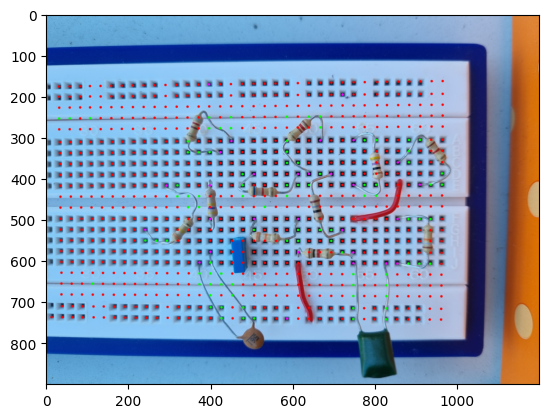

In [3]:
# Choose an image path
image_path = "./bb5.jpg"


im = cv2.imread(image_path)

# Run Grid generation
grid_img, intersections, grid_size, row_count, col_count = grid_generation(im)

plt.imshow(cv2.cvtColor(grid_img, cv2.COLOR_BGR2RGB))

# get image dimensions
height, width = im.shape[:2]

gps = classify_grid_points(im, intersections, grid_size, height, width)

class_grid_im = visualise_classified_grid_points(im, gps)
plt.imshow(cv2.cvtColor(class_grid_im, cv2.COLOR_BGR2RGB))

# Dijkstra to connect each Plugged GridPoint to Masked GridPoint 

## Create Graph

In [ ]:
# Use python library for Dijkstra
from dijkstar import Graph, find_path

In [ ]:
# Createa a Map with key as Grid Coordinate and Value being Grid Point Object
grid_map = {}
# Find the list of Grid Points that are plugged in
plugged_gps = []
for gp in gps:
    grid_map[gp.get_coordinates()] = gp
    if gp.is_plugged():
        plugged_gps.append(gp)

In [ ]:
# For each GridPoint, if it is Pass Over, create edges to its neighbour based on the wire connectivity of the gridPoint
graph = Graph()

for gp in gps:
    if gp.type == 1:  # Pass Over
        r, c = gp.get_coordinates()
        # Check 8 directions
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]